In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve, make_swiss_roll
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import math


In [9]:
4920/3

1640.0

In [10]:

from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


In [11]:

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


### 1.1 IMS dataset
This time we will adopt the real dataset. The experiment will used the IMS dataset and also the phm2012 dataset.
First we will consider the IMS dataset, specifically the No.2 dataset No. 3 bearing (channel).


The test rig can be seen below:


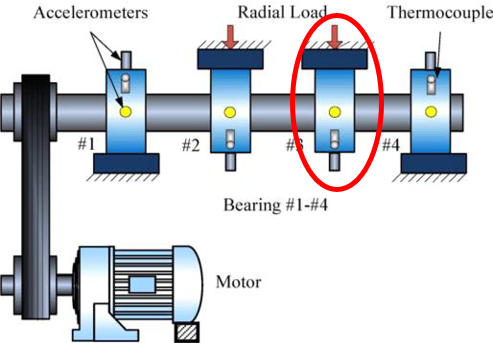



### Training the model using the time-domain data

In [12]:
import scipy.io as scio
from sklearn.model_selection import train_test_split
import pandas as pd

# dict_o = scio.loadmat(r'D:/Work in EPFL/diffusion_model/Ramanujan_Dictionary_DDPM/IMS_data/N2_data_C3_.mat')
#dict_o = pd.read_csv('AE_Diffusion/AE_data_ims/data_f.csv')
dict_oh = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_001.mat')
data_oh = dict_oh['a_y']
# y_oh = np.zeros(600,1)
dict_ou001 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_01.mat')
data_ou001 = dict_ou001['a_y']
dict_ou01 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_1.mat')
data_ou01 = dict_ou01['a_y']
dict_ou05 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_0_5.mat')
data_ou05 = dict_ou05['a_y']
dict_ou1 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_1_0.mat')
data_ou1 = dict_ou1['a_y']
dict_ou10 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_10_0.mat')
data_ou10 = dict_ou10['a_y']
dict_ou100 = scio.loadmat('AE_Diffusion/AE_data_ims/data_bou_100_0.mat')
data_ou100 = dict_ou100['a_y']

def normalize(data):
    data_ = (data-np.min(data))/(np.max(data)-np.min(data))
    return data_
data_h_ = np.zeros((400,512))
data_u001 = np.zeros((400,512))
data_u01 = np.zeros((400,512))
data_u05 = np.zeros((400,512))
data_u1 = np.zeros((400,512))
data_u100 = np.zeros((400,512))
for i in range(400):
  data_h_[i,:] = normalize(data_oh[0,40*i:40*i+512])
  data_h_[i,:] = data_oh[0,40*i:40*i+512]
for i in range(400):
  data_u001[i,:] = normalize(data_ou001[0,40*i:40*i+512])
  data_u001[i,:] = data_ou001[0,40*i:40*i+512]
for i in range(400):
  data_u01[i,:] = normalize(data_ou01[0,40*i:40*i+512])
  data_u01[i,:] = data_ou01[0,40*i:40*i+512]
for i in range(400):
  data_u05[i,:] = normalize(data_ou05[0,40*i:40*i+512])
  data_u05[i,:] = data_ou05[0,40*i:40*i+512]
for i in range(400):
  data_u1[i,:] = normalize(data_ou1[0,40*i:40*i+512])
  data_u1[i,:] = data_ou1[0,40*i:40*i+512]
for i in range(400):
  data_u100[i,:] = normalize(data_ou100[0,40*i:40*i+512])
  data_u100[i,:] = data_ou100[0,40*i:40*i+512]
data_tva = np.vstack((data_h_,data_u001,data_u01,data_u05,data_u1))

data_tva = data_tva.reshape(-1,1,512)

data_tv = data_h_
# data_tv = np.vstack((data_h_,data_u100))
data_tv = data_tv.reshape(-1,1,512)
# data_test  = data_1[1000:-1,:,:]
yh = np.zeros(400)
# yu = np.ones(400)
y_ = yh
data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.2, random_state=42)
# data_tr = data_tr.view(-1,2048)
# data_va = data_va.view(-1,2048)

batch_size = 16 #考虑到样本总数仅为1000个,batch_size设定为64个
# dataset放到dataloader中
dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32).cuda(),torch.tensor(y_1,dtype = torch.float32).cuda())
#dataloader_1 = torch.utils.data.DataLoader(torch.tensor(data_tr,dtype=torch.float32).cuda(), batch_size=batch_size, shuffle=True)
dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True)

In [13]:
# # data_b = data_1[4000:4920,:,:]
# # data_tv = np.concatenate((data_h, data_b),axis = 0)
# data_tv = data_h
# # data_test  = data_1[1000:-1,:,:]
# yh = np.zeros(1000)
# # yu = np.ones(920)

# # y_ = np.concatenate((yh,yu))
# y_ = yh
# data_tr,data_va,y_1,y_v = train_test_split(data_tv, y_, test_size=0.2, random_state=42)

# batch_size = 64 #考虑到样本总数仅为1000个,batch_size设定为64个
# # dataset放到dataloader中
# dataset_tensor = torch.utils.data.TensorDataset(torch.tensor(data_tr,dtype=torch.float32).cuda(),torch.tensor(y_1,dtype = torch.float32).cuda())
# #dataloader_1 = torch.utils.data.DataLoader(torch.tensor(data_tr,dtype=torch.float32).cuda(), batch_size=batch_size, shuffle=True)
# dataloader_1 = torch.utils.data.DataLoader(dataset_tensor,batch_size=batch_size, shuffle=True)




#### model construction

In [14]:

import abc
import math
from typing import Tuple, Union
from typing import Tuple, Sequence

import torch
import torch.nn.functional as F
from torch.distributions import Distribution



import torch
from torch.nn import functional as F
from typing import Tuple, List, Iterator, Dict, Callable
from typing import Callable, Dict, Any, Union, Tuple, List, Optional
from collections import defaultdict

import torch.nn
from torch.nn import Parameter

class Loss(torch.nn.modules.loss._Loss, abc.ABC):
    def __init__(self, size_average=None, reduce=None, reduction: str = 'mean'):
        super(Loss, self).__init__(size_average, reduce, reduction)

    @abc.abstractmethod
    def forward(self, predictions: Tuple[torch.Tensor, ...],
                targets: Tuple[torch.Tensor, ...], *args, **kwargs) -> Union[torch.Tensor, Tuple[torch.Tensor]]:
        raise NotImplementedError()

class MLP(torch.nn.Module):
    def __init__(self, input_features: int, hidden_layers: Union[int, Sequence[int]], output_features: int,
                 activation: Callable = torch.nn.Identity(), activation_after_last_layer: bool = False):
        super(MLP, self).__init__()

        self.activation = activation
        self.activation_after_last_layer = activation_after_last_layer

        if isinstance(hidden_layers, int):
            hidden_layers = [hidden_layers]

        layers = [input_features] + list(hidden_layers) + [output_features]
        self.layers = torch.nn.ModuleList([torch.nn.Linear(inp, out) for inp, out in zip(layers[:-1], layers[1:])])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = x
        for layer in self.layers[:-1]:
            out = layer(out)
            out = self.activation(out)

        out = self.layers[-1](out)
        if self.activation_after_last_layer:
            out = self.activation(out)

        return out


In [15]:
import abc
from typing import Tuple

import torch
import tqdm

class DenseVAEEncoder(torch.nn.Module):
    def __init__(self, input_dim: int, hidden_dims: Sequence[int] = (100, 100), latent_dim: int = 10,
                 activation=torch.nn.ReLU()):
        super(DenseVAEEncoder, self).__init__()

        self.latent_dim = latent_dim

        self.mlp = MLP(input_dim, hidden_dims, 2*latent_dim, activation=activation, activation_after_last_layer=False)
        self.softplus = torch.nn.Softplus()

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # x: (B, T, D)
        mlp_out = self.mlp(x)

        mean, std = mlp_out.tensor_split(2, dim=-1)
        std = self.softplus(std)

        return mean, std

class AnomalyDetector(torch.nn.Module, abc.ABC):
    def __init__(self):
        super(AnomalyDetector, self).__init__()

        # We use this empty parameter to determine the device of the detector
        self.register_buffer('dummy', torch.tensor([]), persistent=False)

    @abc.abstractmethod
    def compute_online_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Compute the online anomaly score for a batch of inputs. The output tensor must have the same shape as the
        output of `format_targets` when called with the corresponding targets for this batch. This method expects
        a window (or a batch of windows) as its input and should return a score for the last point in the window.

        :param inputs: tuple of input tensors
        :return: Tensor of shape (B,) that contains the anomaly scores for this batch
        """
        raise NotImplementedError

    @abc.abstractmethod
    def compute_offline_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Compute the offline anomaly score for a batch of inputs. The output tensor must have the same shape as the
        output of `format_targets` when called with the corresponding targets for this batch. This method expects
        a window (or a batch of windows) as its input and should return a score for the last point in the window.

        :param inputs: tuple of input tensors
        :return: Tensor of shape (N,) that contains the anomaly scores for this batch
        """
        raise NotImplementedError

    @abc.abstractmethod
    def fit(self, dataset: torch.utils.data.DataLoader) -> None:
        """
        Fit this anomaly detector on a dataset. Note that we assume only normal data here.

        :param dataset: A dataset
        """
        raise NotImplementedError

    @abc.abstractmethod
    def format_online_targets(self, targets: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Format the labels for a batch of targets. The output tensor must have the same shape as the
        output of `compute_online_anomaly_score` when called with the corresponding inputs for this batch.

        :param targets: tuple of target tensors
        :return: Tensor of shape (B,) that contains the ground truth labels for this batch
        """
        raise NotImplementedError

    def forward(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        return self.compute_online_anomaly_score(inputs)

    def get_labels_and_scores(self, dataset: torch.utils.data.DataLoader) -> Tuple[torch.Tensor, torch.Tensor]:
        # Collect all labels and scores from the dataset
        labels, scores = [], []

        for batch in tqdm.tqdm(dataset):
            batch_inputs, batch_labels = batch
            batch_inputs = tuple(b_in.to(self.dummy.device) for b_in in batch_inputs)

            batch_scores = self.compute_online_anomaly_score(batch_inputs)
            batch_labels = self.format_online_targets(batch_labels)

            labels.append(batch_labels.cpu())
            scores.append(batch_scores.cpu())

        labels = torch.cat(labels, dim=0)
        scores = torch.cat(scores, dim=0)

        assert labels.shape == scores.shape

        return labels, scores

In [16]:
from typing import List, Union, Optional, Tuple, Sequence

import torch
import torch.nn as nn


class RNN(nn.Module):
    def __init__(self, layer_type: str, model: str, input_dimension: int, hidden_dimensions: Union[Sequence[int], int],
                 n_recurrent_layers: Optional[int] = None, recurrent_activation: str = 'tanh',
                 recurrent_bias: bool = True, bidirectional: bool = False, projection_size: int = 0,
                 dilation: Optional[Sequence[int]] = None, dropout: float = 0.0):
        """
        General framework of a recurrent neural network.

        :param layer_type: The type of recurrent layer (RNN, LSTM, GRU).
        :type layer_type: str
        :param model: Type of model (s2s, s2as, s2fh, s2mh)
        :type model: str
        :param input_dimension: Number of dimensions of the feature space of the input data.
        :type input_dimension: int
        :param hidden_dimensions: Number of dimensions of each hidden state for all recurrent layers.
        :type hidden_dimensions: Union[List[int], int]
        :param n_recurrent_layers: Number of recurrent layers, if hidden_dimensions is the same for all layers (int).
        :type n_recurrent_layers: Optional[int]
        :param recurrent_activation: Activation function to use in each recurrent layer (has to be defined in torch.nn).
        :type recurrent_activation: str
        :param recurrent_bias: Whether to use bias in the computations of the recurrent layers.
        :type recurrent_bias: bool
        :param bidirectional: Use bidirectional recurrent layers.
        :type bidirectional: bool
        :param projection_size: Parameter relevant for LSTM layers only. See pytorch docs for details.
        :type projection_size: int
        """

        super(RNN, self).__init__()

        if isinstance(hidden_dimensions, int):
            if n_recurrent_layers is None:
                hidden_dimensions = [hidden_dimensions]
            else:
                hidden_dimensions = [hidden_dimensions for _ in range(n_recurrent_layers)]

        if dilation is None:
            dilation = [0 for _ in hidden_dimensions]
        if len(dilation) != len(hidden_dimensions):
            raise ValueError('Dilation must match the number of hidden layers!')
        self.dilation = dilation

        if layer_type.lower() == 'rnn':
            layer = nn.RNN
        elif layer_type.lower() == 'lstm':
            layer = nn.LSTM
        elif layer_type.lower() == 'gru':
            layer = nn.GRU
        elif callable(layer_type):
            layer = layer_type
        else:
            raise NotImplementedError(layer_type)

        layer_kwargs = {'num_layers': 1, 'bias': recurrent_bias,
                        'batch_first': False,
                        'bidirectional': bidirectional}

        if layer_type.lower() == 'lstm':
            layer_kwargs['proj_size'] = projection_size
        elif layer_type.lower() == 'rnn':
            layer_kwargs['nonlinearity'] = recurrent_activation

        self.dropout = torch.nn.Identity() if dropout <= 0.0 else torch.nn.Dropout(dropout)

        dims = [input_dimension] + list(hidden_dimensions)
        self.recurrent_layers = nn.ModuleList([layer(input_size=input_dim, hidden_size=hidden_dim, **layer_kwargs)
                                               for input_dim, hidden_dim in zip(dims[:-1], dims[1:])])

        self.model = model

    def _base_rnn_forward(self,
                          inputs: Union[torch.Tensor, nn.utils.rnn.PackedSequence],
                          hidden_states: Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]] = None,
                          return_all_sequences: bool = False) \
            -> Tuple[Union[List[torch.Tensor], torch.Tensor, nn.utils.rnn.PackedSequence], ...]:
        """
        Apply the base RNN to the sequence and return the hidden states from every step in the sequence.

        :param inputs: Tensor or sequence of shape (T, B, ...)
        :param hidden_states: Hidden states of shape (num_layers, B, ...). For LSTM this must be a tuple of two tensors.
        :param return_all_sequences: Whether the method should return outputs of intermediate layers, too
        :return: If return_all_sequences=False this is a tensor or PackedSequence of shape (T, B, ...),
            otherwise a list of such tensors with one element for each layer is returned.
        """

        # LSTM needs two tensors for hidden state
        if isinstance(hidden_states, tuple):
            hidden_states = zip(*hidden_states)
        elif hidden_states is None:
            hidden_states = (None for _ in self.recurrent_layers)

        layer_output = inputs
        layer_hidden = None
        outputs = []
        hiddens = []

        for i, (layer, dilation, hidden) in enumerate(zip(self.recurrent_layers, self.dilation, hidden_states)):
            if isinstance(hidden, tuple):
                hidden = tuple(torch.unsqueeze(h, dim=0) for h in hidden)
            elif isinstance(hidden, torch.Tensor):
                hidden = torch.unsqueeze(hidden, dim=0)

            if dilation > 1:
                layer_output, layer_hidden = self.apply_dilated_layer(layer, layer_output, dilation, hidden)
            else:
                layer_output, layer_hidden = layer(layer_output, hidden)

            if i < len(self.recurrent_layers) - 1:
                # Apply dropout, but not after the last layer
                layer_output = self.dropout(layer_output)

            if return_all_sequences:
                outputs.append(layer_output)
                hiddens.append(layer_hidden)

        if return_all_sequences:
            return outputs, hiddens

        return layer_output, layer_hidden

    def apply_dilated_layer(self, layer: torch.nn.Module,
                            inputs: Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence], dilation: int,
                            hidden: Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]] = None) -> \
            Tuple[Union[torch.Tensor, torch.nn.utils.rnn.PackedSequence],
                  Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]]:
        # TODO: handle packed sequence
        inputs, padding, hidden = self._dilate_inputs(inputs, dilation, hidden)

        outputs, hidden = layer(inputs, hidden)

        outputs = self._restore_outputs(outputs, dilation, padding)

        return outputs, hidden

    @staticmethod
    def _restore_outputs(dilated_outputs: torch.Tensor, dilation: int, input_padding: int) -> torch.Tensor:
        """
        Restores output of a RNN applied to a sequence prepared with _dilate_inputs to its original form.
        That means the subsampled sequences are interleaved again and padding is removed from the end of the sequence.

        :param dilated_outputs: Tensor of shape ((T+padding)//dilation, B*dilation, ...)
        :param dilation: Dilation (subsampling) factor
        :param input_padding: Padding applied to the input sequence before applying the RNN
        :return: Tensor of size (T, B, ...)
        """
        in_shape = dilated_outputs.shape
        batch_size = in_shape[1] // dilation

        blocks = [dilated_outputs[:, i * batch_size: (i + 1) * batch_size] for i in range(dilation)]

        interleaved = torch.stack(blocks).transpose(1, 0).contiguous()
        out_shape = [in_shape[0] * dilation, batch_size] + list(interleaved.shape[3:])
        interleaved = interleaved.view(out_shape)
        if input_padding > 0:
            interleaved = interleaved[:-input_padding]

        return interleaved

    @staticmethod
    def _dilate_inputs(inputs: torch.Tensor, dilation: int, hidden: torch.Tensor = None) -> Tuple[torch.Tensor, int, torch.Tensor]:
        """
        Subsamples the input sequence with a factor of dilation. Each of the first dilation elements is used as
        a starting point for such a subsampled sequence and they are stacked along the batch axis. Note that the
        sequence will be padded with zeros at the end so that its length is a multiple of dilation.

        :param inputs: Tensor of shape (T, B, ...), where T is the sequence length and N the batch size
        :param dilation: Dilation (subsampling) factor
        :param hidden: Tensor of shape (B, hidden_size) containing initial hidden state or a tuple of two such tensors
            in case of the LSTM
        :return: Tensor of shape ((T+padding)//dilation, N*dilation, ...) and the number of time-steps that were
            applied as padding and the new hidden state
        """
        seq_len = inputs.shape[0]
        padding = (seq_len + dilation - 1) // dilation * dilation - seq_len

        if padding > 0:
            pad_shape = [padding] + list(inputs.shape[1:])
            zeros_ = torch.zeros(pad_shape, device=inputs.device, dtype=inputs.dtype)
            inputs = torch.cat((inputs, zeros_))

        dilated_inputs = torch.cat([inputs[j::dilation] for j in range(dilation)], 1)

        if hidden is not None:
            hidden = hidden.repeat(dilation, 1)

        return dilated_inputs, padding, hidden

    def forward(self, inputs: Union[torch.Tensor, nn.utils.rnn.PackedSequence],
                hidden_states: Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]] = None,
                return_hidden: bool = False) \
            -> Union[Tuple[torch.Tensor, ...], torch.Tensor, nn.utils.rnn.PackedSequence]:
        """
        Apply the base RNN to the sequence and return the hidden states from every step in the sequence.

        :param inputs: Tensor or sequence of shape (T, B, ...)
        :param hidden_states: Hidden states of shape (num_layers, B, ...). For LSTM this must be a tuple of two tensors.
        :param return_hidden: Whether the method should return hidden states of the RNN too
        :return: If return_hidden=False this is a tensor or PackedSequence of shape (T, B, ...),
            otherwise a Tuple (output, hidden)
        """
        return_all = False
        if self.model == 's2as':
            return_all = True

        output, hidden = self._base_rnn_forward(inputs, hidden_states, return_all_sequences=return_all)

        if self.model in ['s2s', 's2as']:
            pass
        elif self.model == 's2fh':
            output = output[-1]
        elif self.model == 's2mh':
            output = torch.mean(output, dim=0)
        else:
            raise NotImplementedError(f'Model {self.model} is not supported!')

        if return_hidden:
            return output, hidden
        else:
            return output


In [17]:
from typing import Tuple

import torch
import torch.nn.functional as F



class PlanarTransform(torch.nn.Module):
    """
    Implementation of the invertible transformation used in planar flow
        f(z) = z + u * h(dot(w.T, z) + b)

    See Section 4.1 in https://arxiv.org/pdf/1505.05770.pdf.
    """

    def __init__(self, dim: int, epsilon: float = 1e-4):
        """Initialise weights and bias.

        :param dim: Dimensionality of the distribution to be estimated.
        """
        super().__init__()

        self.epsilon = epsilon

        w = torch.randn(dim)
        w *= 0.1
        self.w = torch.nn.Parameter(w)

        b = torch.randn(1)
        b *= 0.1
        self.b = torch.nn.Parameter(b)

        u = torch.randn(dim)
        u *= 0.1
        self.u = torch.nn.Parameter(u)

    def forward(self, z: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        self.get_u_hat()

        a = torch.tanh(torch.inner(z, self.w) + self.b).unsqueeze(-1)
        y = z + self.u * a

        psi = (1 - a**2) * self.w
        abs_det = (1 + torch.inner(self.u, psi)).abs()
        log_det = torch.log(self.epsilon + abs_det)

        return y, log_det

    def get_u_hat(self) -> None:
        """
        Enforce w^T u >= -1. When using h(.) = tanh(.), this is a sufficient condition
        for invertibility of the transformation f(z). See Appendix A.1.
        """
        wtu = torch.inner(self.u, self.w)
        if wtu >= -1:
            return

        m_wtu = -1 + F.softplus(wtu)
        self.u.data = self.u + (m_wtu - wtu) * self.w / torch.dot(self.w, self.w)



class PlanarFlow(torch.nn.Module):
    def __init__(self, dim: int, num_layers: int = 6):
        """
        Make a planar flow by stacking planar transformations in sequence.

        :param dim: Dimensionality of the distribution to be estimated.
        :param num_layers: Number of transformations in the flow.
        """
        super().__init__()
        self.layers = torch.nn.ModuleList([PlanarTransform(dim) for _ in range(num_layers)])

    def forward(self, z: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        log_det_sum = 0

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum = log_det + log_det_sum

        return z, log_det_sum


In [18]:
class BaseModel(torch.nn.Module):
    def grouped_parameters(self) -> Tuple[Iterator[Parameter], ...]:
        return self.parameters(),


class KalmanFilter(torch.nn.Module):
    def __init__(self, state_dim: int, observation_dim: int):
        super(KalmanFilter, self).__init__()

        self.state_dim = state_dim
        self.observation_dim = observation_dim

        self.F = torch.nn.Parameter(torch.eye(state_dim, dtype=torch.float))
        self.state_cov = torch.nn.Parameter(torch.ones(state_dim, dtype=torch.float))

        H = torch.zeros(observation_dim, state_dim, dtype=torch.float)
        H.diagonal().add_(1)
        self.H = torch.nn.Parameter(H)
        self.obs_cov = torch.nn.Parameter(torch.ones(observation_dim, dtype=torch.float))

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations: (T, L, B, D)
        T, B, D = observations.shape

        assert D == self.observation_dim

        s_cov = F.softplus(self.state_cov)
        obs_cov = F.softplus(self.obs_cov)

        log_likelihood = 0
        state_mean = torch.zeros(B, self.state_dim, dtype=observations.dtype, device=observations.device)
        state_cov = torch.eye(self.state_dim, dtype=observations.dtype, device=observations.device)

        for t in range(T):
            observation = observations[t]
            state_upd_mean = state_mean @ self.F.T
            state_update_cov = self.F @ state_cov @ self.F.T + s_cov.diag_embed()

            innovation = observation - state_upd_mean @ self.H.T
            innovation_cov = self.H @ state_update_cov @ self.H.T + obs_cov.diag_embed()

            expanded_innovation_cov = innovation_cov.view(1, self.observation_dim, self.observation_dim)
            expanded_innovation_cov = expanded_innovation_cov.expand(B, self.observation_dim, self.observation_dim)
            solve_mean = torch.linalg.solve(expanded_innovation_cov, innovation)
            solve_cov = torch.linalg.solve(innovation_cov, self.H)

            PH = state_update_cov @ self.H.T

            state_mean = state_upd_mean + solve_mean @ PH.T
            state_cov = state_update_cov - PH @ solve_cov @ state_update_cov

            log_likelihood = log_likelihood - 0.5 * (torch.inner(innovation, solve_mean) + torch.logdet(innovation_cov)
                                                     + self.observation_dim * math.log(2 * math.pi))

        return log_likelihood


class OmniAnomaly(BaseModel):
    def __init__(self, input_dim: int, latent_dim: int = 3, rnn_hidden_dims: Sequence[int] = (500,),
                 dense_hidden_dims: Sequence[int] = (500, 500), nf_layers: int = 20):
        super(OmniAnomaly, self).__init__()

        self.latent_dim = latent_dim

        self.prior = KalmanFilter(latent_dim, latent_dim)

        self.enc_rnn = RNN('gru', 's2s', input_dim, rnn_hidden_dims)
        self.encoder_vae = DenseVAEEncoder(rnn_hidden_dims[-1] + latent_dim, dense_hidden_dims, latent_dim)
        self.latent_nf = PlanarFlow(latent_dim, num_layers=nf_layers)

        self.decoder_rnn = RNN('gru', 's2s', latent_dim, rnn_hidden_dims)
        self.decoder_vae = DenseVAEEncoder(rnn_hidden_dims[-1], dense_hidden_dims, input_dim)

    def forward(self, inputs: Tuple[torch.Tensor], num_samples: int = 1) -> Tuple[torch.Tensor, torch.Tensor,
                                                                                  torch.Tensor, torch.Tensor,
                                                                                  torch.Tensor, torch.nn.Module,
                                                                                  torch.Tensor, torch.Tensor]:
        # x: (T, B, D)
        x, = inputs
        T, B, D = x.shape

        # Use RNN to encode the input
        hidden = self.enc_rnn(x)
        # Add sample dimension
        hidden = hidden.unsqueeze(1).expand(T, num_samples, B, hidden.shape[-1])

        normal_sample = torch.randn((T+1, num_samples, B, self.latent_dim), dtype=x.dtype, device=x.device)
        z_sample = [normal_sample[0]]
        z_mean, z_std = [], []
        for t in range(T):
            z_t_mean, z_t_std = self.encoder_vae(torch.cat([hidden[t], z_sample[t]], dim=-1))
            z_mean.append(z_t_mean)
            z_std.append(z_t_std)
            # From the paper it might seem that the normalizing flow is used during the sequential computation of z,
            # but in the code this is not the case. We choose to implement it like in the code
            z_sample.append(z_t_std * normal_sample[t+1] + z_t_mean)
        z_mean = torch.stack(z_mean, dim=0)
        z_std = torch.stack(z_std, dim=0)
        z_sample = torch.stack(z_sample[1:], dim=0)

        # Transform samples using a planar normalizing flow
        z_sample_transformed, z_log_det = self.latent_nf(z_sample)

        # Decode. Collapse sample and batch dimension for RNN
        z_sample_transformed = z_sample_transformed.view(T, -1, self.latent_dim)
        dec_hidden = self.decoder_rnn(z_sample_transformed)
        # Restore sample dimension
        dec_hidden = dec_hidden.view(T, num_samples, B, dec_hidden.shape[-1])
        x_rec_mean, x_rec_std = self.decoder_vae(dec_hidden)

        return z_std, z_mean, z_sample, z_sample_transformed, z_log_det, self.prior, x_rec_mean, x_rec_std


class OmniAnomalyLoss(Loss):
    def __init__(self):
        super(OmniAnomalyLoss, self).__init__(reduction='mean')

    def forward(self, predictions: Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor,
                                         torch.nn.Module, torch.Tensor, torch.Tensor],
                targets: Tuple[torch.Tensor, ...], *args, **kwargs) -> torch.Tensor:
        z_std, z_mean, z_sample, z_sample_transformed, z_log_det, prior, x_rec_mean, x_rec_std = predictions
        actual_x, = targets

        # L = sample dimension
        T, L, B, D = x_rec_mean.shape

        nll_output = F.gaussian_nll_loss(x_rec_mean, actual_x.unsqueeze(1), x_rec_std**2, reduction='sum') / (B * L)

        # We cannot compute KL(q(z|x) || p(z)) exactly anymore because q is non-gaussian, so we have to use
        # MC approximation to estimate E_{z~q(z|x)}[log(q(z|x)) - log(p(z))]

        # This is p(z), i.e., the prior likelihood of Z. The paper assumes a linear gaussian state space model
        # aka. a Kalman filter
        ll_prior = torch.mean(prior(z_sample_transformed))

        # log(q(zx)) can be computed from the original sample's density and the NF Jacobian's log det.
        nll_approx = F.gaussian_nll_loss(z_mean, z_sample, z_std**2, reduction='sum') / (B * L)
        nll_approx = nll_approx - torch.sum(z_log_det) / (B * L)

        return nll_output - ll_prior - nll_approx



In [19]:
class OmniAnomalyDetector(AnomalyDetector):
    def __init__(self, model: OmniAnomaly, num_mc_samples: int = 1024):
        """
        We decided not to include the reconstruction step from the paper here, since we don't have missing data.

        :param model:
        :param num_mc_samples:
        """
        super(OmniAnomalyDetector, self).__init__()

        self.model = model
        self.num_mc_samples = num_mc_samples

    def compute_online_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        # We compute not only the log likelihood of the data, but the entire ELBO
        # x: (T, B, D)
        # output (B,)
        x, = inputs

        with torch.no_grad():
            res = self.model(inputs, num_samples=self.num_mc_samples)

        z_std, z_mean, z_sample, z_sample_transformed, z_log_det, prior, x_rec_mean, x_rec_std = res

        # Compute MC approximation of Log likelihood
        nll_output = torch.sum(F.gaussian_nll_loss(x_rec_mean[-1], x[-1].unsqueeze(0),
                                                   x_rec_std[-1]**2, reduction='none'), dim=(0, -1))
        nll_output /= self.num_mc_samples

        return nll_output

    def compute_offline_anomaly_score(self, inputs: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        pass

    def fit(self, dataset: torch.utils.data.DataLoader) -> None:
        pass

    def format_online_targets(self, targets: Tuple[torch.Tensor, ...]) -> torch.Tensor:
        # Input of shape (T, B), output of shape (B,)
        target, = targets
        # Just return the last label of the window
        return target[-1]

In [20]:
# model_T = OmniAnomaly(input_dim = 1).cuda()
# z1 = torch.randn((512,16,1))

# o1,o2,o3,o4,o5,o6,o7,o8 = model_T((z1,))


#### Trying to train the model

In [ ]:
model_T = OmniAnomaly(input_dim = 1).cuda()
num_epoch = 100

seed = 3407
torch.cuda.manual_seed(seed)
dataloader = dataloader_1
optimizer_ = torch.optim.Adam(model_T.parameters(),lr = 1e-4)
loss_ = OmniAnomalyLoss()
num_epoch = 1000

# epoch遍历
for t in range(num_epoch):
    # dataloader遍历
    model_T.train()
    for idx, (batch_x, batch_y) in enumerate(dataloader):
      batch_x = batch_x.permute(2,0,1)
      predictions= model_T((batch_x,))
      targets = (batch_x,)
      optimizer_.zero_grad()
      loss = loss_(predictions,targets)
      loss.backward()
      optimizer_.step()
    print(
            "[Epoch %d/%d]   [loss_ %f] "
                % (t,num_epoch, loss.item())
        )

[Epoch 0/1000]   [loss_ 1757.083740] 
[Epoch 1/1000]   [loss_ -1117.591309] 
[Epoch 2/1000]   [loss_ -1827.562866] 
[Epoch 3/1000]   [loss_ -1020.773682] 
[Epoch 4/1000]   [loss_ -1112.238770] 
[Epoch 5/1000]   [loss_ -1479.871338] 
[Epoch 6/1000]   [loss_ -1699.311523] 
[Epoch 7/1000]   [loss_ -2459.681152] 
[Epoch 8/1000]   [loss_ -2561.253906] 
[Epoch 9/1000]   [loss_ -2025.241089] 
[Epoch 10/1000]   [loss_ -2465.988281] 
[Epoch 11/1000]   [loss_ -2588.206787] 
[Epoch 12/1000]   [loss_ -2582.055908] 
[Epoch 13/1000]   [loss_ -2701.822021] 
[Epoch 14/1000]   [loss_ -2659.082764] 
[Epoch 15/1000]   [loss_ -2787.139648] 
[Epoch 16/1000]   [loss_ -2830.892334] 
[Epoch 17/1000]   [loss_ -2834.040527] 
[Epoch 18/1000]   [loss_ -2875.972900] 
[Epoch 19/1000]   [loss_ -2860.757812] 
[Epoch 20/1000]   [loss_ -2905.239746] 
[Epoch 21/1000]   [loss_ -2881.090576] 
[Epoch 22/1000]   [loss_ -2933.398682] 
[Epoch 23/1000]   [loss_ -2943.199463] 
[Epoch 24/1000]   [loss_ -2990.260742] 
[Epoch 25/1

In [ ]:
# # o1,o2,o3,o4,o5,o6 = model_T((data_tv,))
# data_tv_ = data_tv.reshape(1024,-1,4)
# o3 = o3.reshape(1024,-1,4)
# o4 =o4.reshape(1024,-1,4)
# aa = F.gaussian_nll_loss(o3[-1], data_tv_[-1], o4[-1]**2, reduction='none')

In [ ]:
4920/2


2460.0

In [ ]:
anomaly_scores = torch.ones(2000).cuda()
with torch.no_grad():
  data_tv = torch.tensor(data_tva,dtype = torch.float32).cuda()
  data_tv = data_tv.permute(2,0,1)
  model_T.eval()
  ano_detetcor = OmniAnomalyDetector(model_T)
  for i in range(2000):
    print(i)
    anomaly_scores[i] = ano_detetcor.compute_online_anomaly_score((data_tv[:,i:(i+1),:],))
  # anomaly_scores = ano_detetcor.compute_online_anomaly_score((data_tv,))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
# torch.save('AE_Diffusion/AE_data_ims/anomaly_score_1000_IMS_SIS_VAE.mat',{'anomaly_scores',anomaly_scores.detach().cpu().numpy()})

In [ ]:
HI_m_ = anomaly_scores.detach().cpu().numpy()
HI_m = np.ones(5)
for i in range(5):
  HI_m[i] = np.mean(HI_m_[400*i:400*(i+1)])


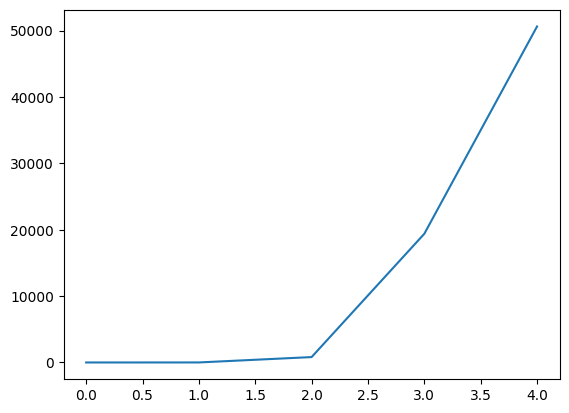

In [ ]:
plt.plot(HI_m)

In [ ]:
import scipy.io as scio
HI_t = HI_m
HI_t_ = HI_m_
scio.savemat('AE_Diffusion/AE_data_ims/result_1000_IMS_omini_VAE.mat',{'HI_t':HI_t,'HI_t_':HI_t_})

#### Case I